# Chronos-2 Quality Net — Results (2026-08-18)

`train/finetune_chronos2.py`, `eval/backtest.py`로 이미 실행해 둔 결과를 불러와 표/그래프로 봅니다.
이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*.csv` 결과 파일만 읽습니다.

이번 실행은 `mill_BF_pressure_delta`/`restart_hr`/`prior_gap_hr`(원본 xlsx에 없던 파생 변수 3개)를
코드·데이터에서 전부 제거한 뒤의 **정식 파이프라인(`data/processed/quality_timeseries.csv`, IQR 적용,
with_iqr/without_iqr 비교 아님)** 기준 결과입니다.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용 (`naive_pred` 컬럼, 체크포인트와 무관하게 동일)
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음
- **LoRA**: 기본 설정(`num_steps=2000, lr=1e-5`)으로 파인튜닝 (`checkpoints/{target}/final`)
- **Full fine-tuning**: 전체 가중치 파인튜닝, `learning_rate=1e-6`(LoRA보다 10배 낮게, LoRA는 원본 참고
  노트북의 관행을 따름) (`checkpoints/{target}_full/final`)

모든 평가는 동일한 test split, 동일한 `--stride 4`, `fresh_reading_only=True`(실측치가 갱신되는 시점만 평가)
기준으로 만들어져 서로 직접 비교 가능합니다.

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

# 이 노트북은 chronos_quality_net 폴더 안에서 실행된다고 가정 (config.py가 같은 폴더에 있어야 함)
ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

# method label -> csv tag
METHOD_TAGS = {
    "zero-shot": "zeroshot",
    "LoRA": "lora",
    "Full fine-tuning": "full",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}  # results[target][method] -> DataFrame (identical for all methods except *_pred cols)
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

`eval/backtest.py`와 동일한 방식으로 계산합니다 (naive_pred 컬럼이 naive baseline).

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         66.4835  90.7461  0.4192         0.7031  1007   
        LoRA              66.5047  90.8511  0.4179         0.7021  1007   
        Full fine-tuning  66.2373  91.0308  0.4156         0.7061  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4396   0.6071  0.8172         0.7967   979   
        LoRA               0.4392   0.6053  0.8182         0.8049   979   
        Full fine-tuning   0.4370   0.5987  0.8222         0.8110   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.4101  
        LoRA                         0.4141  
        Full fine-tuning             0.4121  
residue naive                           NaN  
        zero-shot                    0.3963  
        LoRA                         0.3963  
        Full fine-tuning             0.4188

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

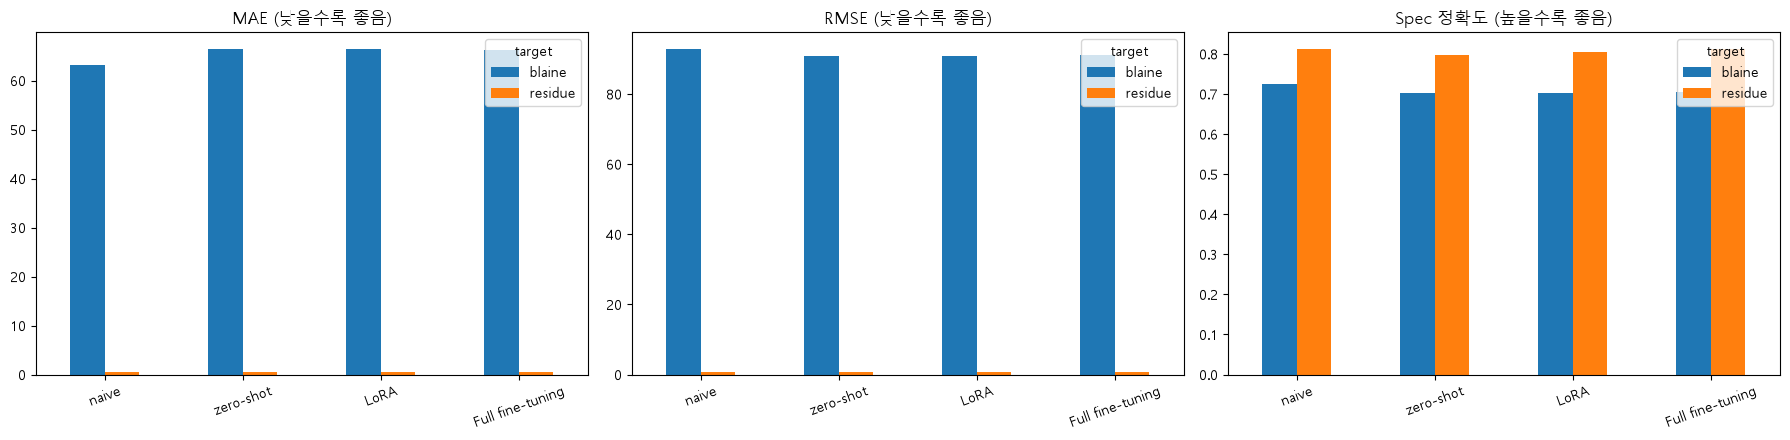

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

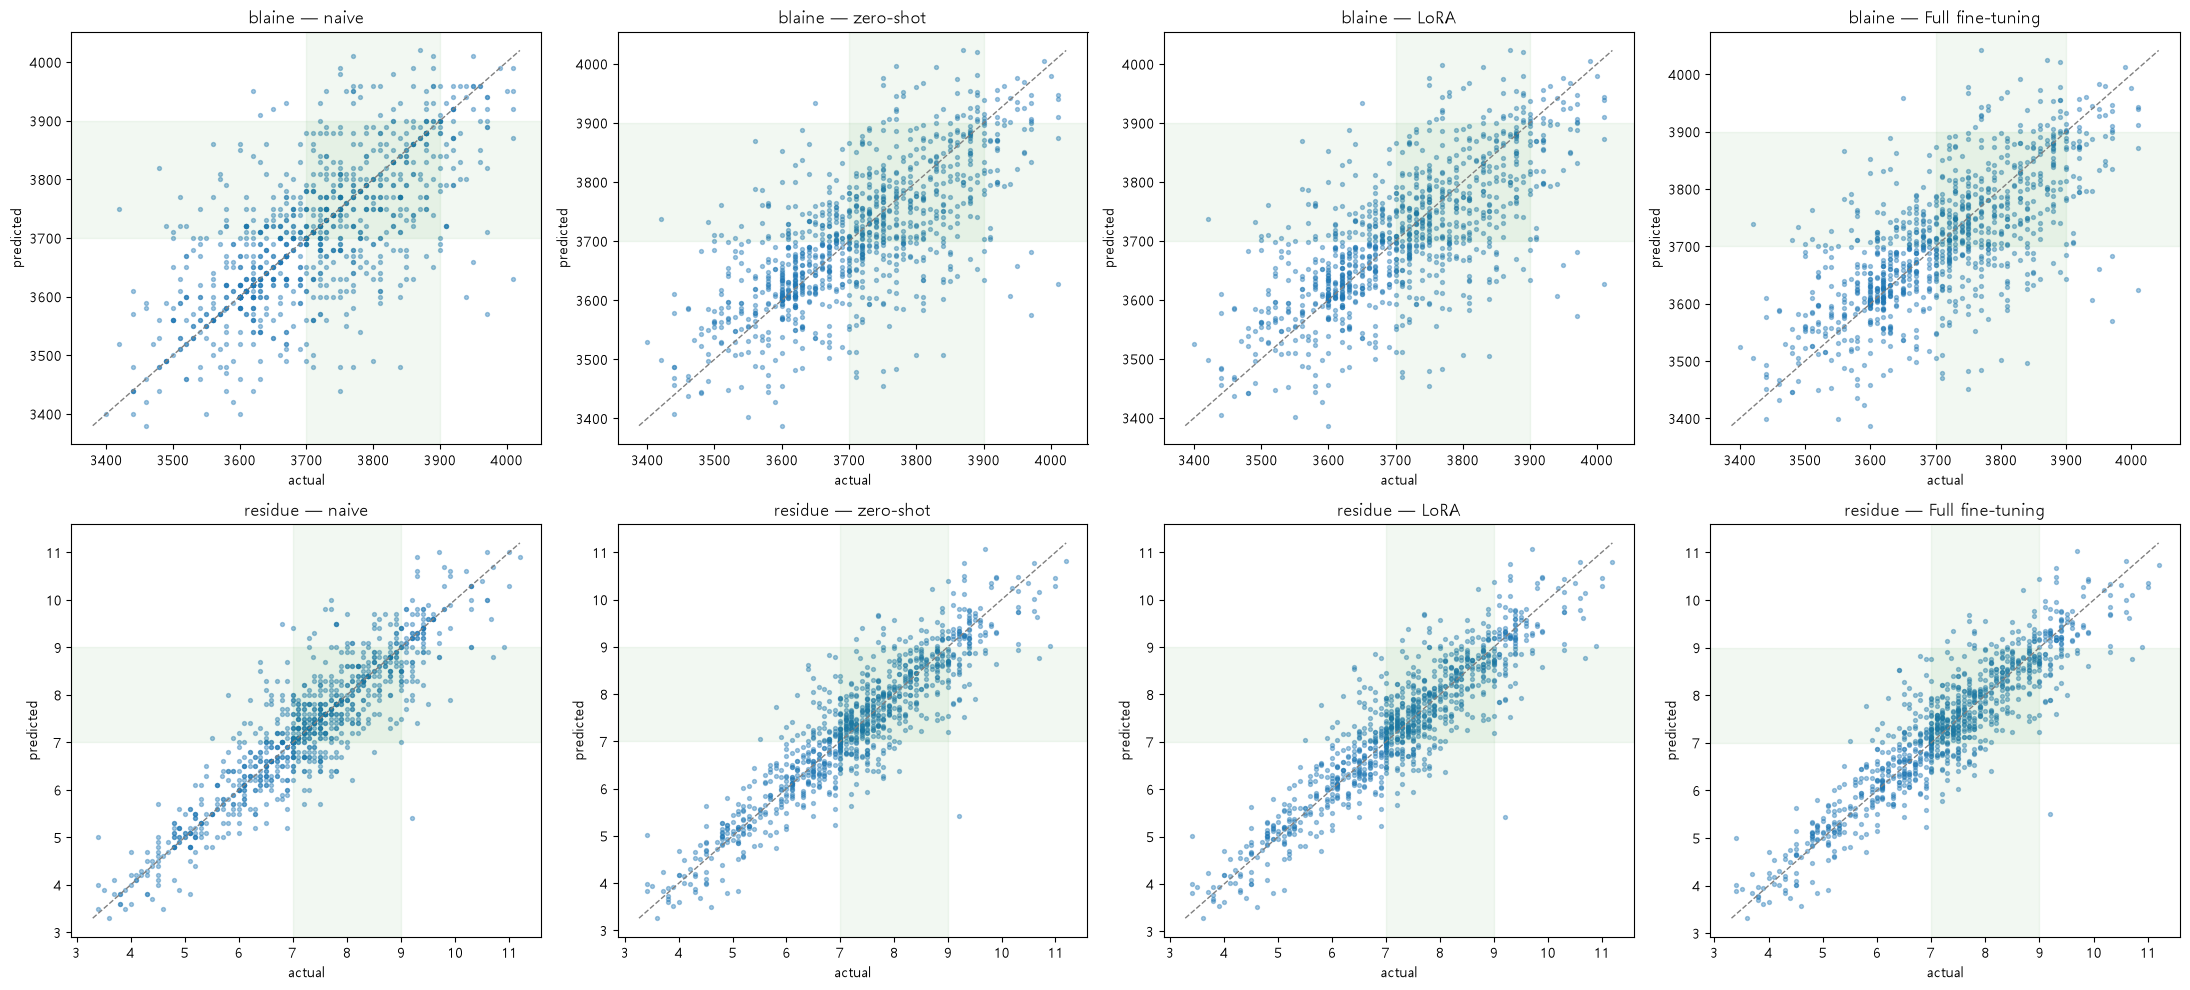

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

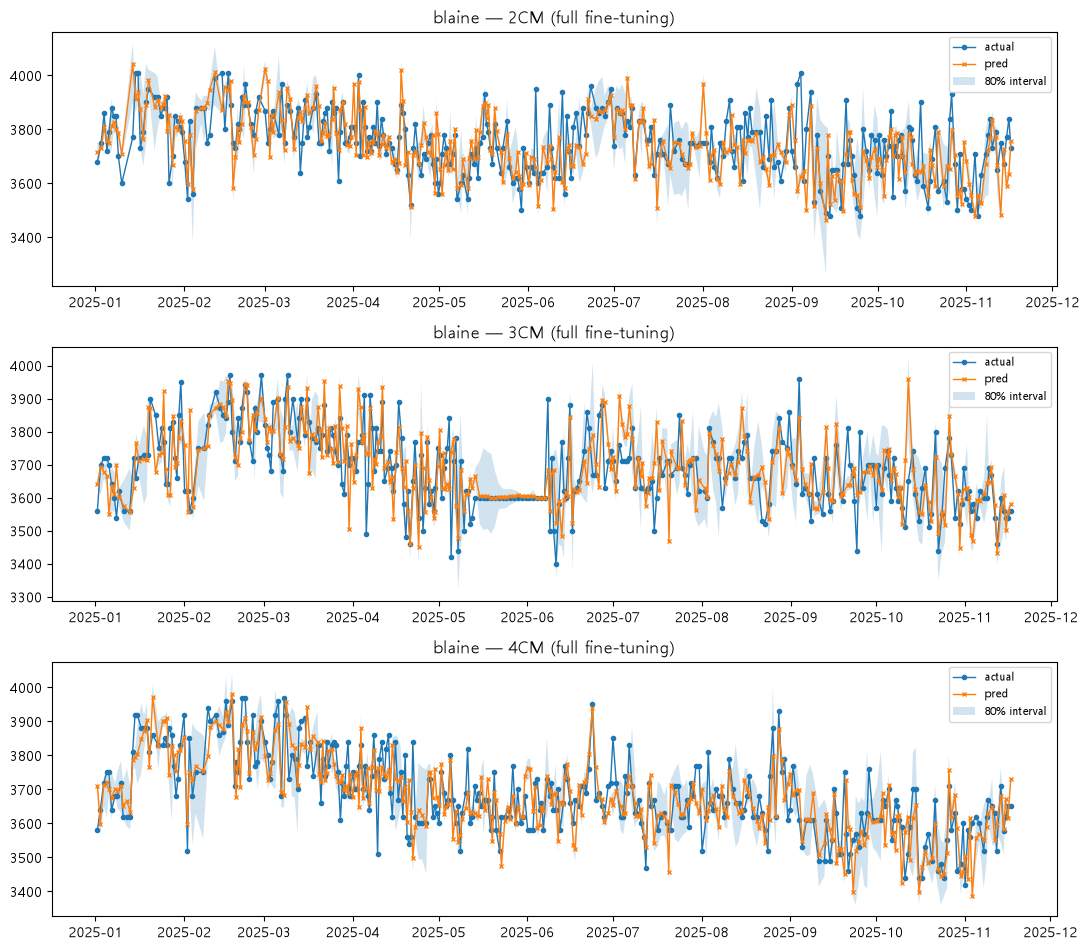

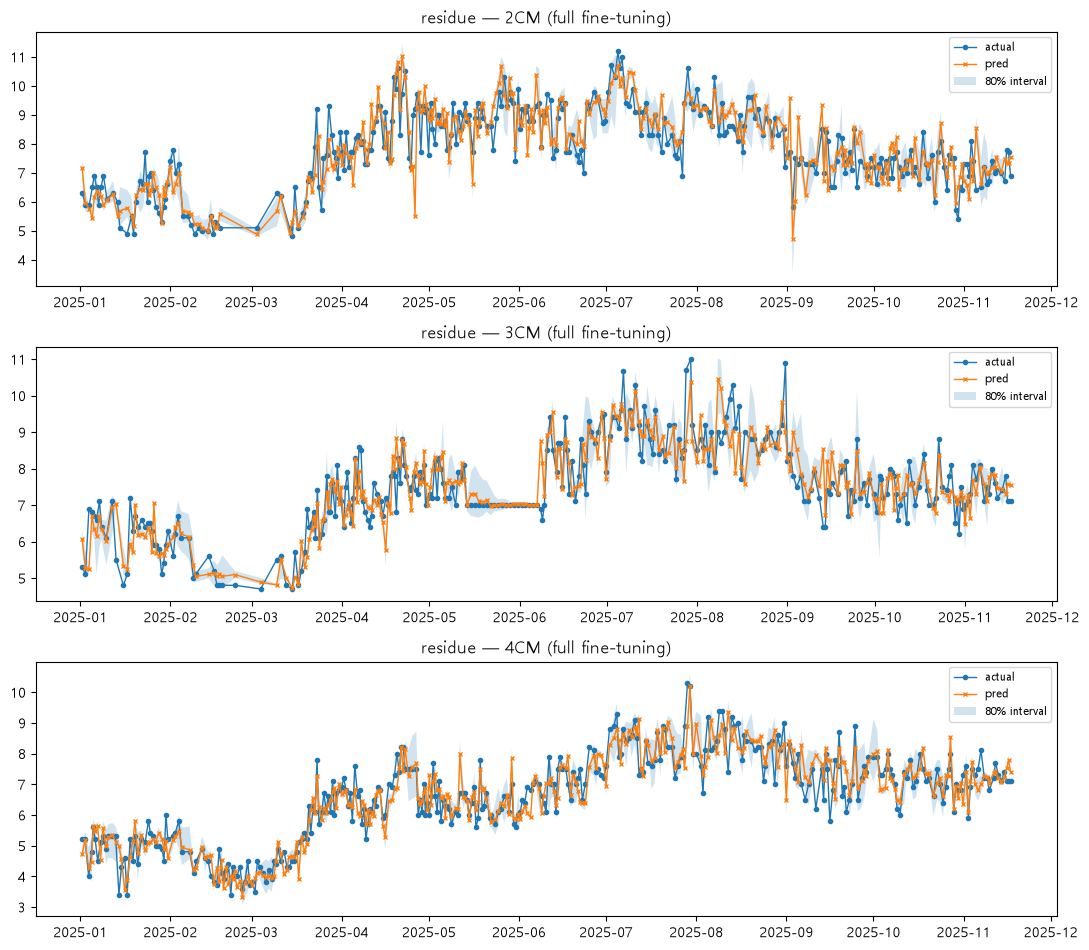

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

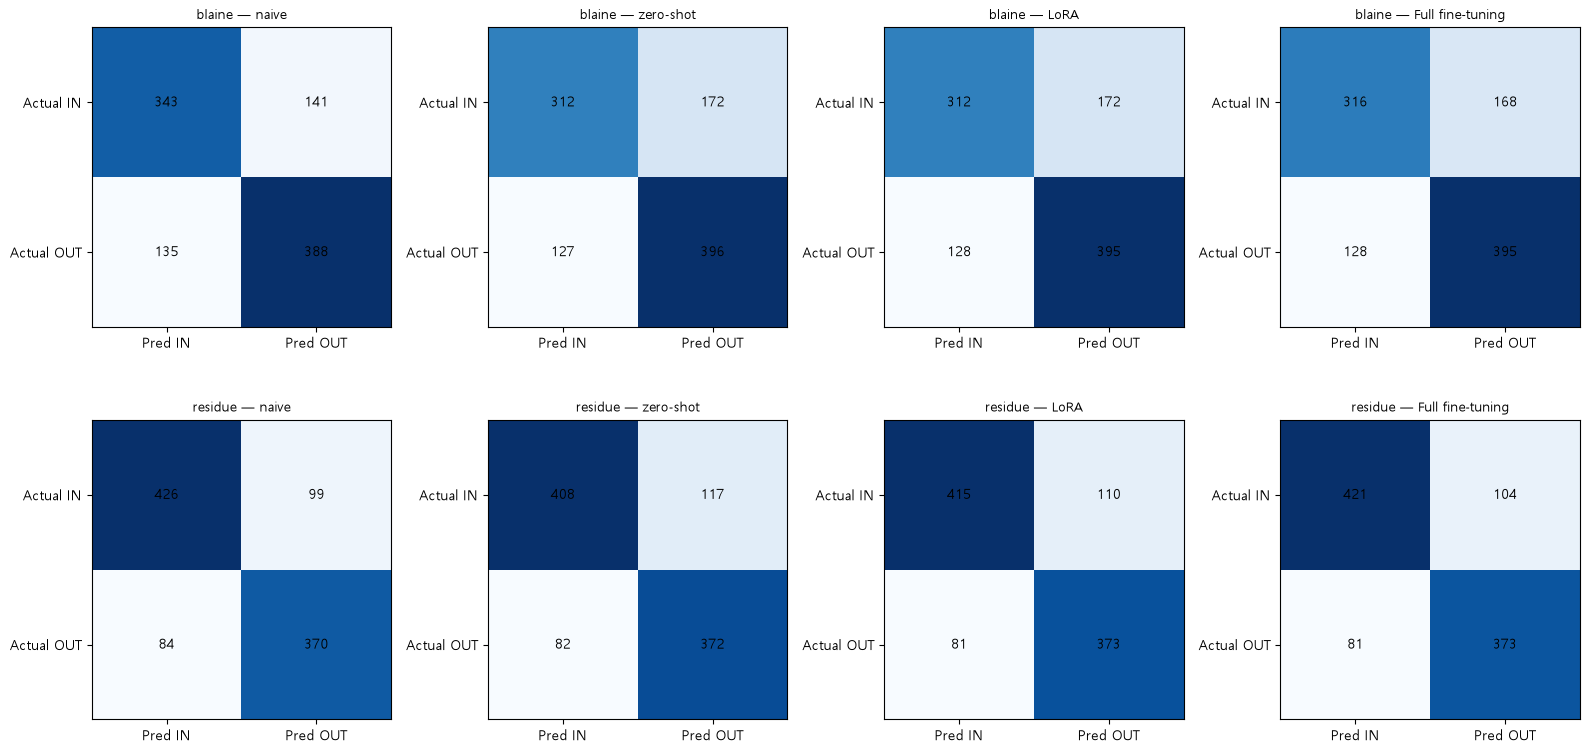

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

- **세 방식(zero-shot / LoRA / full) 간 차이는 여전히 크지 않습니다.** blaine은 MAE 66.2~66.5, spec 정확도
  70.2~70.6% 범위에서 거의 붙어있고, 파인튜닝(LoRA/full)이 zero-shot 대비 뚜렷한 개선을 보이지 않습니다.
- **residue는 full fine-tuning이 처음으로 naive baseline과 거의 대등한 수준까지 올라왔습니다**
  (spec 정확도: naive 81.31% vs full 81.10%, R²: naive 0.8091 vs full **0.8222**로 오히려 앞섬).
  zero-shot(79.67%)·LoRA(80.49%)보다도 full이 가장 나은 결과입니다 — 다만 아직 naive의 spec 정확도를
  확실히 앞서진 못했습니다.
- **blaine은 세 방식 모두 여전히 naive baseline(MAE 63.21)보다 못합니다** (66.2~66.5). 강한 노이즈를 가진
  타깃이라는 점(지난번 분석에서 확인한 낮은 자기상관)이 계속 발목을 잡는 것으로 보입니다.
- **80% 예측구간 커버리지는 39~42%대로 여전히 목표(80%)에 크게 못 미침** — 파인튜닝 방식을 바꿔도
  전혀 개선되지 않아, 불확실성 과신 문제는 학습 방식과 무관한 별도 이슈로 보입니다.
- 종합하면 full fine-tuning이 residue에서는 가장 유망한 방향이지만, blaine과 구간 커버리지 문제는
  여전히 해결되지 않은 상태입니다.

자세한 실험 이력: `EXPERIMENT_LOG.md` 참고.